In [1]:
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
from pydantic import BaseModel , Field
from typing import Annotated
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph , START ,END
from langgraph.graph.message import add_messages
from langgraph.checkpoint.memory import InMemorySaver


c:\Users\TECH DRONA\Desktop\GEN_Ai\env\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1


In [3]:
class ChatState(BaseModel):
    messages: Annotated[list,add_messages]


In [4]:
llm = ChatGroq(model="openai/gpt-oss-20b")

In [5]:
def chatBotNode(state:ChatState) -> ChatState:
    res = llm.invoke(state.messages)
    state.messages = [res]
    return state

In [6]:
memory = InMemorySaver()

In [7]:
graph = StateGraph(ChatState)
graph.add_node("chatBot",chatBotNode)

graph.add_edge(START,"chatBot")
graph.add_edge("chatBot",END)

graph = graph.compile(checkpointer=memory)

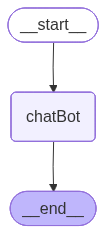

In [8]:
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())

In [11]:
config = {"configurable":{"thread_id":"my-bot-1"}}
res = graph.invoke(
    {"messages":[{"role":"user","content":"what is my name"}]},
    config
    )

In [12]:
res["messages"][-1].content

'You’re Vivek\u202fKushwaha!'